In [2]:
import json

# Replace 'experiment_data.json' with the path to your JSON file
with open('../data_experiment/data13/experiment_data.json', 'r') as file:
    original_data = json.load(file)

with open('../data_experiment/data12/experiment_data.json', 'r') as file:
    experiment_filtered_data = json.load(file)

with open('../data_experiment/data12/experiment_data copy 2.json', 'r') as file:
    experiment_fully_filtered_data = json.load(file)

    
data = original_data

In [2]:
# formating data

import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

# Function to calculate precision at k
def calculate_precision(ratings):
    precisions = []
    relevant_count = 0
    
    for k, rating in enumerate(ratings, start=1):
        if int(rating) >= 3:  # Consider rating >= 3 as relevant
            relevant_count += 1
        precisions.append(relevant_count / k)
    
    return precisions

more_rattings = {}
# Function to get ideal ranking for a given taskName and questionKey
def get_ideal_ranking(data, task_name, question_key):
    issue_ratings = defaultdict(list)
    
    for student in data.get("student_data", {}).values():
        for task in student.get("tasks", []):
            if task.get("taskName") == task_name:
                solutions = task.get("solutions", {}).get(question_key, [])
                for solution in solutions:
                    for rating in solution.get("ratings", []):
                        issue_ratings[rating['issue_id']].append(int(rating['rating']))
    
    for issue_id, ratings in issue_ratings.items():
        if len(ratings) > 1 and (max(ratings) - min(ratings)) > 2:
            more_rattings[task_name + question_key + issue_id] = ratings
    # Calculate average ratings and sort by descending order
    averaged_ratings = {issue_id: np.max(ratings) for issue_id, ratings in issue_ratings.items()}
    # averaged_ratings = {issue_id: np.mean(ratings) for issue_id, ratings in issue_ratings.items()}
    
    sorted_issues = sorted(averaged_ratings.items(), key=lambda x: x[1], reverse=True)
    return [rating for _, rating in sorted_issues[:10]]  # Return top 10 ratings
    return [issue_id for issue_id, _ in sorted_issues[:10]]  # Return top 10 issue_ids

# Function to store ideal rankings for all taskName and questionKey combinations
def store_ideal_rankings(data):
    ideal_rankings = {}
    
    for student in data.get("student_data", {}).values():
        for task in student.get("tasks", []):
            task_name = task.get("taskName")
            for question_key in task.get("solutions", {}).keys():
                # Get ideal ranking for each taskName and questionKey
                ideal_rankings.setdefault(task_name, {})
                ideal_rankings[task_name][question_key] = get_ideal_ranking(data, task_name, question_key)
    
    return ideal_rankings

# Function to calculate DCG
def calculate_dcg(ratings, k):
    # return sum((2**r - 1) / np.log2(idx + 2) for idx, r in enumerate(ratings[:k]))

    return sum(r / np.log2(idx + 2) for idx, r in enumerate(ratings[:k]))

# Function to calculate NDCG
def calculate_ndcg(ratings, ideal_ratings, k):
    dcg = calculate_dcg(ratings, k)
    idcg = calculate_dcg(ideal_ratings, k)
    # if dcg> idcg:
    #     print(ratings, ideal_ratings)
        
    #     print(dcg, idcg)
    
    return dcg / idcg if idcg > 0 else 0

# Extract and calculate precision data
precision_data = []
taskDetails = data.get("task_details", {})
ideal_rankings = store_ideal_rankings(data)

# ideal_rankings
# print(ideal_rankings)
for student_id, student in data.get("student_data", {}).items():
    for task in student.get("tasks", []):
        task_name = task.get("taskName")
        rerank_engine = task.get("rerank_engine", False)
        gpt = task.get("gpt", False)
        if "Component" in task_name:
            task_type = "Component"
        else:
            task_type = "Requirement"
        
        for question_key, solutions in task.get("solutions", {}).items():
            question_type = taskDetails.get(task_name, {}).get("questions", {}).get(question_key, {}).get("type", "none")
            # print(student_id,question_key,question_type)
            
            for solution in solutions:
                
                ratings = [int(issue['rating']) for issue in solution.get("ratings", [])]
                
                precisions = calculate_precision(ratings)
                
                
                for k, precision in enumerate(precisions, start=1):
                    ndcg = calculate_ndcg(ratings, ideal_rankings[task_name][question_key],k)
                    # print( ideal_rankings[task_name][question_key])
                    
                    # print(task_type, task_name, question_key, rerank_engine, gpt, k, precision)
                    precision_data.append({
                        "Student ID": student_id,
                        "Task Name": task_name,
                        "Task Type": task_type,
                        "Question Key": question_key,
                        "Question Type": question_type,
                        "Rerank Engine": rerank_engine,
                        "GPT": gpt,
                        "K": k,
                        "Precision": precision,
                        "NDCG": float(ndcg)
                    })
df = pd.DataFrame(precision_data)
# print(len(more_rattings),more_rattings)

# Calculate the total number of unique students in the DataFrame
total_students = df['Student ID'].nunique()

print(f"Total number of students in the experiment: {total_students}")

total_queries = len(df)

print(f"Total number of queries performed: {total_queries/10}")

top_students = df['Student ID'].value_counts().head(30)
top_students
print(f"top students top_students",top_students)



Total number of students in the experiment: 24
Total number of queries performed: 680.0
top students top_students Student ID
st0458    310
st2018    300
st5003    300
st0371    300
st8934    290
st8756    290
st9904    290
st3180    280
st3476    280
st6231    280
st7149    280
st4390    280
st9427    280
st3017    280
st6601    280
st1472    280
st4805    280
st7165    280
st8593    280
st1092    280
st6348    280
st9210    280
st2546    270
st0563    250
Name: count, dtype: int64


Rerank Engine, GPT Normal Engine, No GPT NDCG
K=1: Mann-Whitney U test (stat=16733.500, p=0.040) - Significant
K=2: Mann-Whitney U test (stat=17595.000, p=0.003) - Significant
K=3: Mann-Whitney U test (stat=18049.500, p=0.001) - Significant
K=4: Mann-Whitney U test (stat=17999.500, p=0.001) - Significant
K=5: Mann-Whitney U test (stat=17996.000, p=0.001) - Significant
K=6: Mann-Whitney U test (stat=18105.500, p=0.000) - Significant
K=7: t-test (stat=3.263, p=0.001) - Significant
K=8: t-test (stat=3.230, p=0.001) - Significant
K=9: Mann-Whitney U test (stat=17968.500, p=0.001) - Significant
K=10: Mann-Whitney U test (stat=17930.500, p=0.001) - Significant


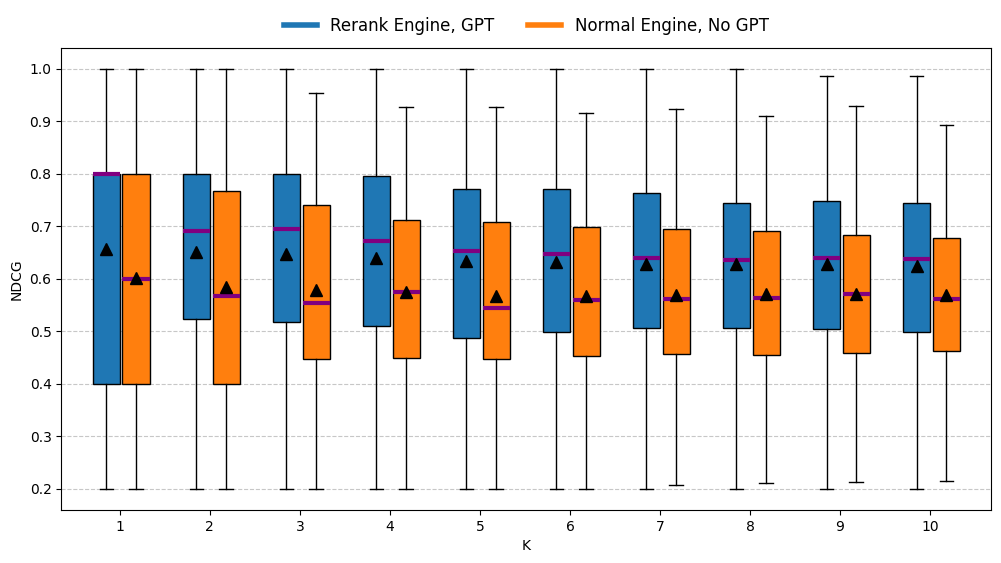

Rerank Engine, No GPT Normal Engine, No GPT NDCG
K=1: Mann-Whitney U test (stat=15402.500, p=0.380) - Not Significant
K=2: Mann-Whitney U test (stat=16464.000, p=0.043) - Significant
K=3: Mann-Whitney U test (stat=16697.500, p=0.023) - Significant
K=4: Mann-Whitney U test (stat=16838.000, p=0.011) - Significant
K=5: Mann-Whitney U test (stat=16873.500, p=0.010) - Significant
K=6: Mann-Whitney U test (stat=16925.500, p=0.009) - Significant
K=7: Mann-Whitney U test (stat=16956.500, p=0.008) - Significant
K=8: Mann-Whitney U test (stat=16695.500, p=0.013) - Significant
K=9: Mann-Whitney U test (stat=16645.000, p=0.015) - Significant
K=10: Mann-Whitney U test (stat=16685.000, p=0.013) - Significant


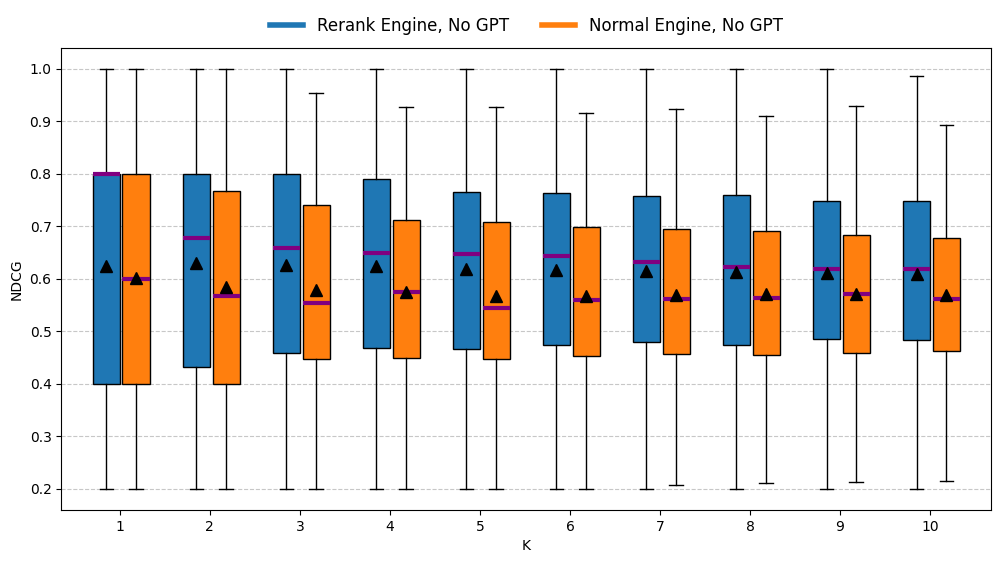

Rerank Engine, GPT Normal Engine, No GPT Precision
K=1: Mann-Whitney U test (stat=16489.000, p=0.032) - Significant
K=2: Mann-Whitney U test (stat=18031.000, p=0.000) - Significant
K=3: Mann-Whitney U test (stat=18410.500, p=0.000) - Significant
K=4: Mann-Whitney U test (stat=18256.500, p=0.000) - Significant
K=5: Mann-Whitney U test (stat=18398.000, p=0.000) - Significant
K=6: Mann-Whitney U test (stat=18609.500, p=0.000) - Significant
K=7: Mann-Whitney U test (stat=18198.000, p=0.000) - Significant
K=8: Mann-Whitney U test (stat=18124.000, p=0.000) - Significant
K=9: Mann-Whitney U test (stat=18133.500, p=0.000) - Significant
K=10: Mann-Whitney U test (stat=17998.500, p=0.001) - Significant


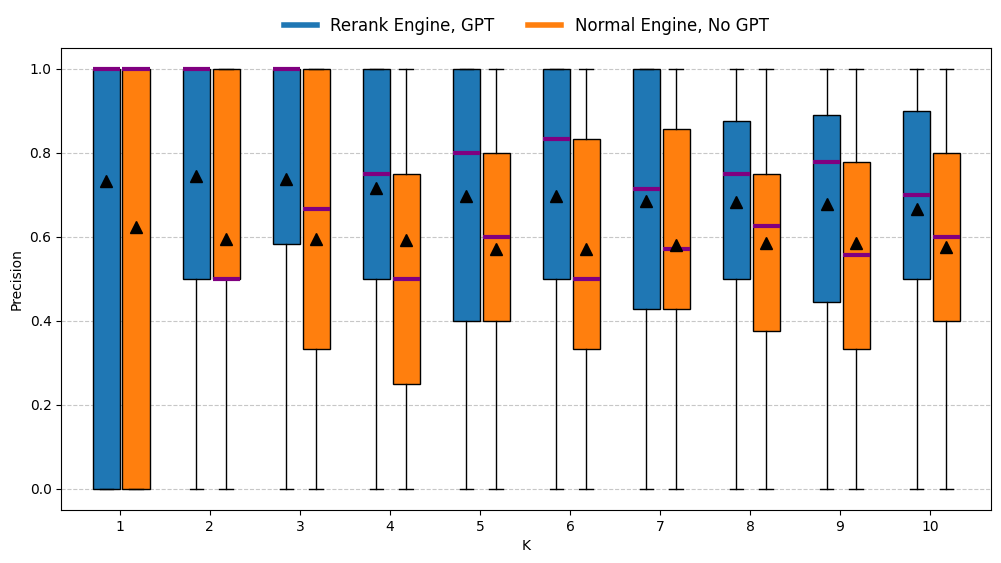

Rerank Engine, No GPT Normal Engine, No GPT Precision
K=1: Mann-Whitney U test (stat=15180.500, p=0.459) - Not Significant
K=2: Mann-Whitney U test (stat=16310.000, p=0.045) - Significant
K=3: Mann-Whitney U test (stat=16514.500, p=0.030) - Significant
K=4: Mann-Whitney U test (stat=16566.000, p=0.021) - Significant
K=5: Mann-Whitney U test (stat=16961.500, p=0.007) - Significant
K=6: Mann-Whitney U test (stat=16889.000, p=0.009) - Significant
K=7: Mann-Whitney U test (stat=16581.500, p=0.023) - Significant
K=8: Mann-Whitney U test (stat=16145.500, p=0.058) - Not Significant
K=9: Mann-Whitney U test (stat=16051.500, p=0.074) - Not Significant
K=10: Mann-Whitney U test (stat=16199.500, p=0.052) - Not Significant


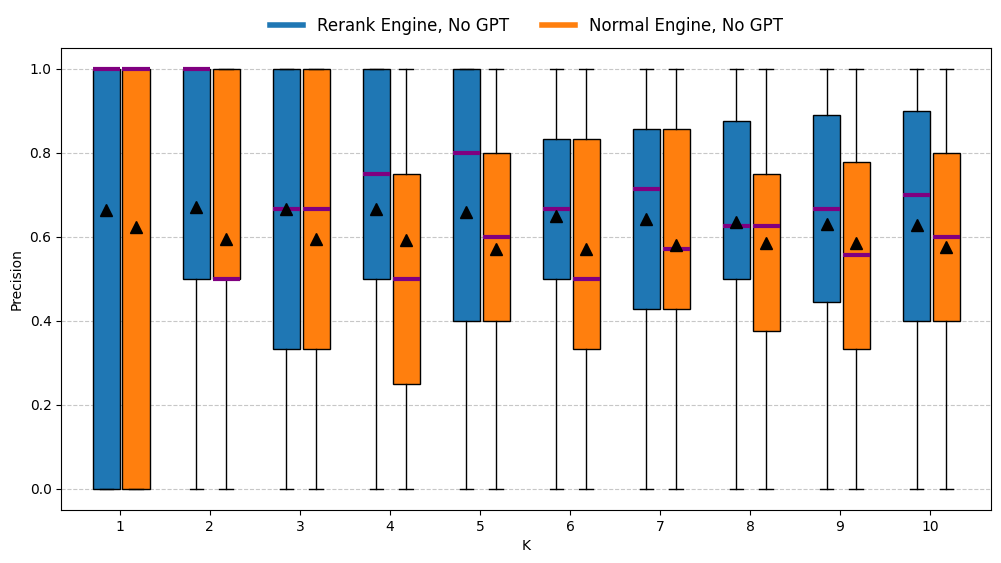

In [3]:


# Generate box plots for precision at each k
def generate_box_plots(df, metric_column):
    metric_by_k = [group[metric_column].values for _, group in df.groupby('K')]
    plt.figure(figsize=(12, 6))
    for i in range(10):
        # Calculate quartiles and IQR
        q1 = np.percentile(metric_by_k[i], 25)
        q2 = np.percentile(metric_by_k[i], 50)
        q3 = np.percentile(metric_by_k[i], 75)
        iqr = q3 - q1
        # Calculate upper and lower bounds for outliers
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        filtered_data = [val for val in metric_by_k[i] if lower_bound <= val <= upper_bound]
        metric_by_k[i] = filtered_data

    plt.boxplot(metric_by_k, labels=range(1, 11))
    plt.title(f'{metric_column} at K (K=1 to 10)')
    plt.xlabel('K')
    plt.ylabel(metric_column)
    plt.grid(True)
    plt.show()

# Define combinations of rerank_engine and gpt
def generate_pattern_box_plots(df, metric_column, patterns):
    # Group data by K and patterns, prepare for box plots
    plot_data = {k: [] for k in range(1, 11)}
    pattern_labels = []

    for pattern in patterns:
        pattern_label = f'Rerank: {pattern["Rerank Engine"]}, GPT: {pattern["GPT"]}'
        pattern_labels.append(pattern_label)
        
        # Filter data for the current pattern
        filtered_df = df[(df["Rerank Engine"] == pattern["Rerank Engine"]) & (df["GPT"] == pattern["GPT"])]
        
        # Group by K and collect metric values
        for k, group in filtered_df.groupby('K'):
            plot_data[k].append(group[metric_column].values)

    # Create the plot
    plt.figure(figsize=(20, 8))

    # Prepare box plots for each K
    positions = np.arange(1, 11)  # Base positions for each K
    width = 0.2  # Space between box plots for different patterns

    for i, pattern_label in enumerate(pattern_labels):
        offset = i * width  # Offset for each pattern
        current_positions = positions + offset
        P_data = [plot_data[k][i] for k in range(1, 11)]
        plt.boxplot(P_data, positions=current_positions, widths=width, showmeans=True, showfliers=True, patch_artist=True, 
                    boxprops=dict(facecolor=f"C{i}"), medianprops=dict(color='purple', linewidth=3), meanprops=dict(markerfacecolor='black', markeredgecolor='black', markersize=8))  # Colorize each pattern differently

    # Customize the plot
    plt.xticks(positions + width * 1.5, labels=range(1, 11))  # Center labels for each K
    plt.title(f"{metric_column} Box Plots for Each K (Grouped by Patterns)")
    plt.xlabel("K")
    plt.ylabel(metric_column)
    plt.legend(handles=[plt.Line2D([0], [0], color=f"C{i}", lw=4, label=pattern_label) 
                        for i, pattern_label in enumerate(pattern_labels)], loc='upper right')
    plt.show()

from scipy.stats import shapiro, ttest_ind, mannwhitneyu
import matplotlib.pyplot as plt
import numpy as np



def generate_significance_test_box_plots(df, metric_column, pattern1, pattern2, plot_title ="overall",extra=""):
    
    # Labels for the patterns
    label1 = f'{"Rerank Engine" if pattern1["Rerank Engine"] else "Normal Engine"}, {"GPT" if pattern1["GPT"] else "No GPT"}'
    label2 = f'{"Rerank Engine" if pattern2["Rerank Engine"] else "Normal Engine"}, {"GPT" if pattern2["GPT"] else "No GPT"}'

    
    # Filter data for each pattern
    df1 = df[(df["Rerank Engine"] == pattern1["Rerank Engine"]) & (df["GPT"] == pattern1["GPT"])]
    df2 = df[(df["Rerank Engine"] == pattern2["Rerank Engine"]) & (df["GPT"] == pattern2["GPT"])]

    significance_results = []
    print(label1, label2, metric_column)

    for k in range(1, 11):  # Iterate over K values
        data1 = df1[df1["K"] == k][metric_column].values
        data2 = df2[df2["K"] == k][metric_column].values

        # Check normality for both datasets using Shapiro-Wilk test
        normal1 = shapiro(data1).pvalue > 0.05
        normal2 = shapiro(data2).pvalue > 0.05

        # Perform t-test or Mann-Whitney U test based on normality
        if normal1 and normal2:
            stat, pvalue = ttest_ind(data1, data2)
            test_used = "t-test"
        else:
            stat, pvalue = mannwhitneyu(data1, data2)
            test_used = "Mann-Whitney U test"
        
        significance_results.append({
            "K": k,
            "Test": test_used,
            "Statistic": stat,
            "p-value": pvalue,
            "Significant": pvalue < 0.05
        })

    # Display results
    for result in significance_results:
        print(f"K={result['K']}: {result['Test']} (stat={result['Statistic']:.3f}, p={result['p-value']:.3f}) - "
              f"{'Significant' if result['Significant'] else 'Not Significant'}")

    # Boxplot visualization
    plt.figure(figsize=(12, 6))
    positions = np.arange(1, 11)
    width = 0.3

    handles = []
    for i, (data, label) in enumerate([(df1, label1), (df2, label2)]):
        offset = i * width * 1.1
        current_positions = positions + offset
        P_data = [data[data["K"] == k][metric_column].values for k in range(1, 11)]
        
        bp = plt.boxplot(
            P_data, 
            positions=current_positions, 
            widths=width, 
            showmeans=True, 
            showfliers=False, 
            patch_artist=True,
            boxprops=dict(facecolor=f"C{i}"), 
            medianprops=dict(color='purple', linewidth=3), 
            meanprops=dict(markerfacecolor='black', markeredgecolor='black', markersize=8)
        )

        # Calculate and display the mean values above each box
        # for j, k in enumerate(range(1, 11)):
        #     mean_val = np.mean(P_data[j]) if len(P_data[j]) > 0 else None
        #     if mean_val is not None:
        #         plt.text(current_positions[j], mean_val, f"{mean_val:.2f}", 
        #                 ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')

        handles.append(plt.Line2D([0], [0], color=f"C{i}", lw=4, label=label))

    plt.xticks(positions + width / 2, labels=[str(k) for k in range(1, 11)])
    # plt.title(plot_title)
    plt.xlabel("K")
    plt.ylabel(metric_column)
    # plt.grid(True)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    # Adjust legend position to top center
    plt.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1.1), ncol=2, fontsize=12, frameon=False)
    plt.savefig(f"{plot_title}/{metric_column}_{label1}_{label2}{extra}.pdf", dpi=300, bbox_inches='tight')

    plt.show()
# Example usage
patterns = [
    {"Rerank Engine": True, "GPT": True},
    {"Rerank Engine": False, "GPT": True},
    {"Rerank Engine": True, "GPT": False},
    {"Rerank Engine": False, "GPT": False},
]
# generate_significance_test_box_plots(df,"NDCG",pattern1=patterns[0],pattern2=patterns[1])
# generate_significance_test_box_plots(df,"NDCG",pattern1=patterns[0],pattern2=patterns[2])
generate_significance_test_box_plots(df,"NDCG",pattern1=patterns[0],pattern2=patterns[3])

# generate_significance_test_box_plots(df,"NDCG",pattern1=patterns[1],pattern2=patterns[2])
# generate_significance_test_box_plots(df,"NDCG",pattern1=patterns[1],pattern2=patterns[3])
generate_significance_test_box_plots(df,"NDCG",pattern1=patterns[2],pattern2=patterns[3])


# generate_significance_test_box_plots(df,"Precision",pattern1=patterns[0],pattern2=patterns[1])
# generate_significance_test_box_plots(df,"Precision",pattern1=patterns[0],pattern2=patterns[2])
generate_significance_test_box_plots(df,"Precision",pattern1=patterns[0],pattern2=patterns[3])

# generate_significance_test_box_plots(df,"Precision",pattern1=patterns[1],pattern2=patterns[2])
# generate_significance_test_box_plots(df,"Precision",pattern1=patterns[1],pattern2=patterns[3])
generate_significance_test_box_plots(df,"Precision",pattern1=patterns[2],pattern2=patterns[3])



# generate_pattern_box_plots(df, 'NDCG', patterns)
# # Example usage
# generate_box_plots(df, 'Precision')
# generate_box_plots(df, 'NDCG')


In [43]:
df

# def filter_data(task_type, question_type):
#     filtered_df = df[(df['Task Type'] == task_type) & (df['Question Type'] == question_type)]
#     return filtered_df

component_df = df[(df['Task Type'] == "Component")]
component_df
requirement_df = df[(df['Task Type'] == "Requirement")]

print("requirement precision")
# generate_significance_test_box_plots(requirement_df,"Precision",pattern1=patterns[0],pattern2=patterns[3],plot_title="components",extra="- requirement")
# print("component precision")
# generate_significance_test_box_plots(component_df,"Precision",pattern1=patterns[0],pattern2=patterns[3],plot_title="components",extra="- component")

# print("requirement NDCG")
# generate_significance_test_box_plots(requirement_df,"NDCG",pattern1=patterns[0],pattern2=patterns[3],plot_title="components",extra="- requirement")
# print("component NDCG")
# generate_significance_test_box_plots(component_df,"NDCG",pattern1=patterns[0],pattern2=patterns[3],plot_title="components",extra="- component")



existence_df = df[(df['Question Type'] == "existence")]
existence_df
executive_df = df[(df['Question Type'] == "executive")]
executive_df
property_df = df[(df['Question Type'] == "property")]
property_df
# print("existence precision")
# generate_significance_test_box_plots(existence_df,"Precision",pattern1=patterns[0],pattern2=patterns[3],plot_title="questions",extra="- existence")
# print("executive precision")
# generate_significance_test_box_plots(executive_df,"Precision",pattern1=patterns[0],pattern2=patterns[3],plot_title="questions",extra="- executive")
# print("property precision")
# generate_significance_test_box_plots(property_df,"Precision",pattern1=patterns[0],pattern2=patterns[3],plot_title="questions",extra="- property")


# print("existence NDCG")
# generate_significance_test_box_plots(existence_df,"NDCG",pattern1=patterns[0],pattern2=patterns[3],plot_title="questions",extra="- existence")
# print("executive NDCG")
# generate_significance_test_box_plots(executive_df,"NDCG",pattern1=patterns[0],pattern2=patterns[3],plot_title="questions",extra="- executive")
# print("property NDCG")
# generate_significance_test_box_plots(property_df,"NDCG",pattern1=patterns[0],pattern2=patterns[3], plot_title="questions",extra="- property")



import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_line_graphs(data_array, metric_column, plot_title ="",extra=""):
    """
    Create line graphs for an array of dictionaries containing DataFrame and label.
    
    Parameters:
    - data_array: List of dictionaries, each with keys 'data' (DataFrame) and 'label' (string)
    - metric_column: The column in the DataFrame to be plotted on the y-axis
    
    Example input:
    data_array = [
        {"data": df1, "label": "Pattern 1"},
        {"data": df2, "label": "Pattern 2"}
    ]
    """
    plt.figure(figsize=(12, 6))

    for entry in data_array:
        df = entry["data"]
        label = entry["label"]
        
        # Group data by K and calculate the mean of the metric for each K
        grouped_data = df.groupby("K")[metric_column].mean()
        
        # Plot the line graph
        plt.plot(grouped_data.index, grouped_data.values, marker='o', label=label)
    
    # Customize the plot
    plt.title(f"{metric_column} Line Graph across K", fontsize=16)
    plt.xlabel("K", fontsize=14)
    plt.ylabel(metric_column, fontsize=14)
    plt.xticks(np.arange(1, 11), fontsize=12)
    plt.yticks(fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.savefig(f"{plot_title}/{metric_column}_line_chart.pdf", dpi=300, bbox_inches='tight')
    
    plt.show()
def calculate_significance(df1, df2 ,metric_column,label1,label2):
    
    significance_results = []
    # Labels for the patterns
    # label1 = f'"Rerank Engine, {"GPT" if pattern1["GPT"] else "No GPT"}'
    # label2 = f'{"Rerank Engine" if pattern2["Rerank Engine"] else "Normal Engine"}, {"GPT" if pattern2["GPT"] else "No GPT"}'

    print(label1, label2, metric_column)

    for k in range(1, 11):  # Iterate over K values
        data1 = df1[df1["K"] == k][metric_column].values
        data2 = df2[df2["K"] == k][metric_column].values

        # Check normality for both datasets using Shapiro-Wilk test
        normal1 = shapiro(data1).pvalue > 0.05
        normal2 = shapiro(data2).pvalue > 0.05

        # Perform t-test or Mann-Whitney U test based on normality
        if normal1 and normal2:
            stat, pvalue = ttest_ind(data1, data2)
            test_used = "t-test"
        else:
            stat, pvalue = mannwhitneyu(data1, data2)
            test_used = "Mann-Whitney U test"
        
        significance_results.append({
            "K": k,
            "Test": test_used,
            "Statistic": stat,
            "p-value": pvalue,
            "Significant": pvalue < 0.05
        })

    # Display results
    for result in significance_results:
        print(f"K={result['K']}: {result['Test']} (stat={result['Statistic']:.3f}, p={result['p-value']:.3f}) - "
              f"{'Significant' if result['Significant'] else 'Not Significant'}")

    
print(len(existence_df),len(executive_df),len(property_df),len(component_df),len(requirement_df))
new_df = df[(df["Rerank Engine"] == True) & (df["GPT"] == True)]
existence_df = existence_df[(existence_df["Rerank Engine"] == True) & (existence_df["GPT"] == True)]
executive_df = executive_df[(executive_df["Rerank Engine"] == True) & (executive_df["GPT"] == True)]
property_df = property_df[(property_df["Rerank Engine"] == True) & (property_df["GPT"] == True)]
component_df = component_df[(component_df["Rerank Engine"] == True) & (component_df["GPT"] == True)]
requirement_df = requirement_df[(requirement_df["Rerank Engine"] == True) & (requirement_df["GPT"] == True)]
print(len(existence_df),len(executive_df),len(property_df),len(component_df),len(requirement_df))

data_array = [
    {"data": new_df, "label": "All Data"},
    # {"data": component_df, "label": "component"},
    # {"data": requirement_df, "label": "requirement"},
    {"data": existence_df, "label": "existence"},
    {"data": executive_df, "label": "executive"},
    {"data": property_df, "label": "property"}
]
calculate_significance(existence_df, executive_df, "Precision","existence","executive")
calculate_significance(existence_df, property_df, "Precision","existence","property")
calculate_significance(executive_df, property_df, "Precision","executive","property")

calculate_significance(existence_df, executive_df, "NDCG","existence","executive")
calculate_significance(existence_df, property_df, "NDCG","existence","property")
calculate_significance(executive_df, property_df, "NDCG","executive","property")

# plot_line_graphs(data_array, metric_column="NDCG",plot_title="questions")
# plot_line_graphs(data_array, metric_column="Precision",plot_title="questions")

data_array = [
    {"data": new_df, "label": "All Data"},
    {"data": component_df, "label": "component"},
    {"data": requirement_df, "label": "requirement"},
    # {"data": existence_df, "label": "existence"},
    # {"data": executive_df, "label": "executive"},
    # {"data": property_df, "label": "property"}
]

calculate_significance(component_df, requirement_df, "Precision","component","requirement")
calculate_significance(component_df, requirement_df, "NDCG","component","requirement")
# plot_line_graphs(data_array, metric_column="NDCG",plot_title="components")
# plot_line_graphs(data_array, metric_column="Precision",plot_title="components")
# top_students = df['Student ID'].value_counts().head(30)
# top_students


requirement precision
2010 1900 2890 3900 2900
510 470 740 1040 680
existence executive Precision
K=1: Mann-Whitney U test (stat=1326.500, p=0.256) - Not Significant
K=2: Mann-Whitney U test (stat=1400.000, p=0.111) - Not Significant
K=3: Mann-Whitney U test (stat=1328.000, p=0.327) - Not Significant
K=4: Mann-Whitney U test (stat=1385.500, p=0.168) - Not Significant
K=5: Mann-Whitney U test (stat=1360.000, p=0.241) - Not Significant
K=6: Mann-Whitney U test (stat=1303.000, p=0.452) - Not Significant
K=7: Mann-Whitney U test (stat=1334.000, p=0.331) - Not Significant
K=8: Mann-Whitney U test (stat=1349.500, p=0.280) - Not Significant
K=9: Mann-Whitney U test (stat=1394.000, p=0.162) - Not Significant
K=10: Mann-Whitney U test (stat=1402.500, p=0.145) - Not Significant
existence property Precision
K=1: Mann-Whitney U test (stat=1814.000, p=0.618) - Not Significant
K=2: Mann-Whitney U test (stat=1745.500, p=0.392) - Not Significant
K=3: Mann-Whitney U test (stat=1667.000, p=0.216) - Not 

In [ ]:
import json

# # Load the JSON file
# with open("experiment_data.json", "r") as file:
#     data = json.load(file)

# Mapping task names to short codes
task_mapping = {
    "Component DataNode": "C_1",
    "Component NameNode": "C_2",
    "Component DiskBalancer": "C_3",
    "Component BlockManagement": "C_4",
    "Component Tools": "C_5",
    "Component Qjournal": "C_6",
    "Requirement File Permissions and Security": "R_1",
    "Requirement Recoverability": "R_2",
    "Requirement Scalability": "R_3",
    "Requirement Rack Awareness": "R_4",
    "Requirement Safe Mode": "R_5",
    "Requirement Upgrade and Rollback":"R_6"
}

def get_task_code(task):
    engine = "R" if task["rerank_engine"] else "N"
    gpt = "G" if task["gpt"] else "N"
    task_id = task_mapping.get(task["taskName"], "Unknown")
    return f"{engine}{gpt}  ${{{task_id}}}$"

# Process each student's task assignments
students = data["student_data"]
table_rows = []

for student_id, details in students.items():
    tasks = details["tasks"]
    task_codes = [get_task_code(task) for task in tasks]
    table_rows.append(f"{len(table_rows) + 1} & " + " & ".join(task_codes) + " \\\\")

# Generate LaTeX table
latex_code = """
\begin{table}
\centering
\caption{Student Task Assignments}
\label{tab:student_tasks}
\begin{tabular}{llllll}
\toprule
Student ID & Index & Task 1 & Task 2 & Task 3 & Task 4 \\
\midrule
"""
latex_code += "\n".join(table_rows)
latex_code += "\n\\bottomrule\n\end{tabular}\n\end{table}"

# Save to file
with open("student_tasks.tex", "w") as tex_file:
    tex_file.write(latex_code)

print("LaTeX table generated and saved as student_tasks.tex")


LaTeX table generated and saved as student_tasks.tex
